In [ ]:
# At the end of Day 2, you should be able to answer:

# What does the dataset look like?
# Are there any obvious data quality issues?
# Which variables seem related to diabetes?
# What questions should my model answer?

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [123]:
#Load the dataset
#df = pd.read_csv("DiabetesDataSets/diabetes_012_health_indicators_BRFSS2015.csv")
df = pd.read_csv("DiabetesDataSets/diabetes_binary_5050split_health_indicators_BRFSS2015.csv")
#df = pd.read_csv("DiabetesDataSets/diabetes_binary_health_indicators_BRFSS2015.csv")
#Display the first few rows
print(df.head())

   Diabetes_binary  HighBP  HighChol  CholCheck   BMI  Smoker  Stroke  \
0              0.0     1.0       0.0        1.0  26.0     0.0     0.0   
1              0.0     1.0       1.0        1.0  26.0     1.0     1.0   
2              0.0     0.0       0.0        1.0  26.0     0.0     0.0   
3              0.0     1.0       1.0        1.0  28.0     1.0     0.0   
4              0.0     0.0       0.0        1.0  29.0     1.0     0.0   

   HeartDiseaseorAttack  PhysActivity  Fruits  ...  AnyHealthcare  \
0                   0.0           1.0     0.0  ...            1.0   
1                   0.0           0.0     1.0  ...            1.0   
2                   0.0           1.0     1.0  ...            1.0   
3                   0.0           1.0     1.0  ...            1.0   
4                   0.0           1.0     1.0  ...            1.0   

   NoDocbcCost  GenHlth  MentHlth  PhysHlth  DiffWalk  Sex   Age  Education  \
0          0.0      3.0       5.0      30.0       0.0  1.0   4.0   

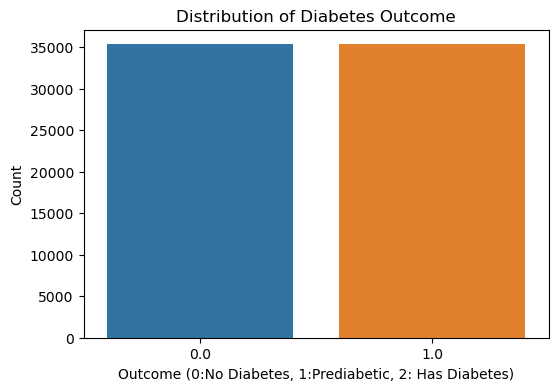

In [114]:
#Visualizae the distribution of target variable
plt.figure(figsize=(6,4))
sns.countplot(x='Diabetes_binary', data=df)
plt.title('Distribution of Diabetes Outcome')
plt.xlabel('Outcome (0:No Diabetes, 1:Prediabetic, 2: Has Diabetes)')
plt.ylabel('Count')
plt.show()

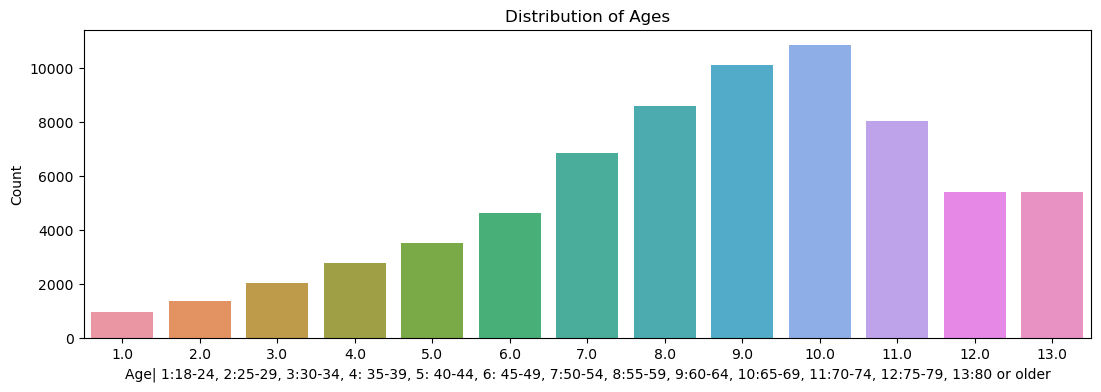

In [115]:
#Visualizae the distribution of target variable
plt.figure(figsize=(13,4))
sns.countplot(x='Age', data=df)
plt.title('Distribution of Ages')
plt.xlabel('Age| 1:18-24, 2:25-29, 3:30-34, 4: 35-39, 5: 40-44, 6: 45-49, 7:50-54, 8:55-59, 9:60-64, 10:65-69, 11:70-74, 12:75-79, 13:80 or older')
plt.ylabel('Count')
plt.show()

C:\Users\HP\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


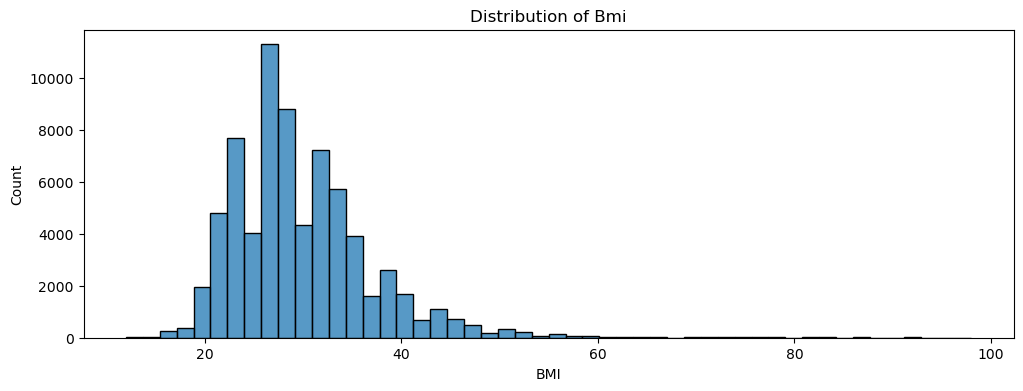

In [116]:
plt.figure(figsize=(12,4))
sns.histplot(data=df, x='BMI', bins=50)
plt.title('Distribution of Bmi')
plt.xlabel('BMI')
plt.ylabel('Count')
plt.show()

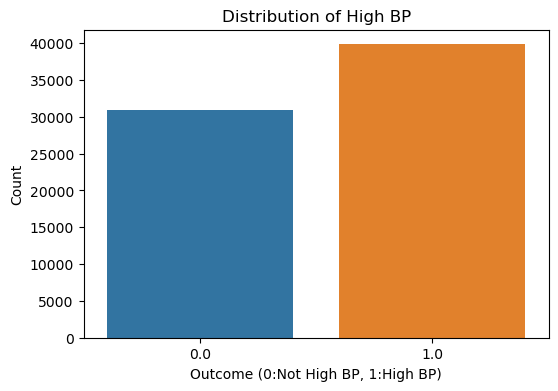

In [117]:
#Visualizae the distribution of target variable
plt.figure(figsize=(6,4))
sns.countplot(x='HighBP', data=df)
plt.title('Distribution of High BP')
plt.xlabel('Outcome (0:Not High BP, 1:High BP)')
plt.ylabel('Count')
plt.show()

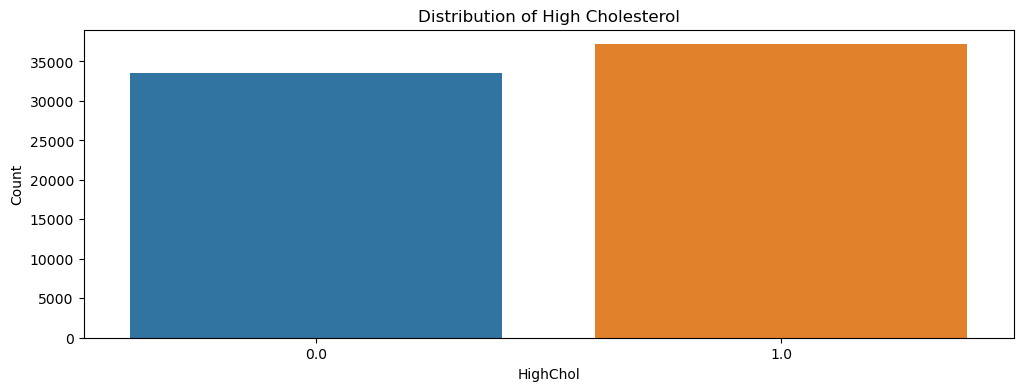

In [118]:
plt.figure(figsize=(12,4))
sns.countplot(data=df, x='HighChol')
plt.title('Distribution of High Cholesterol')
plt.xlabel('HighChol')
plt.ylabel('Count')
plt.show()

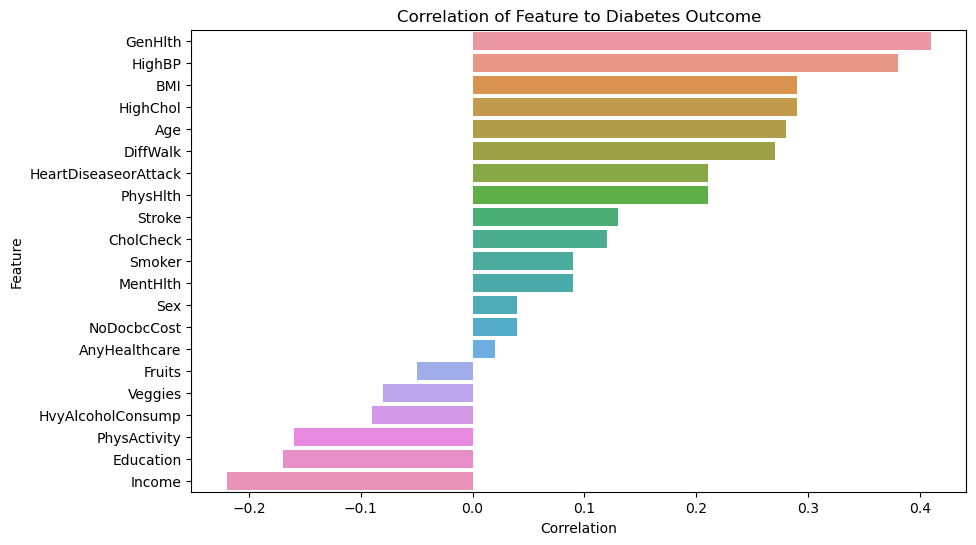

In [120]:
#Highest correlation vs Diabetes_binary
diabetes_corr = (
    df.corr().round(2)["Diabetes_binary"]
        .drop("Diabetes_binary")
        .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=diabetes_corr.values,
    y=diabetes_corr.index
)

plt.title("Correlation of Feature to Diabetes Outcome")
plt.xlabel("Correlation")
plt.ylabel("Feature")
plt.show()

AttributeError: 'numpy.float64' object has no attribute 'startswith'

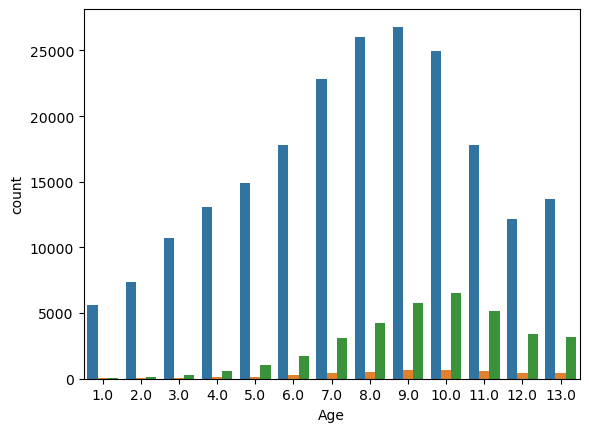

In [21]:
# Age group distribution
sns.countplot(x='Age', data=df, hue='Diabetes_012')
plt.title('Age Distribution')
plt.xlabel('Age Group | 1 = 18-24 ... 9 = 60-64 ... 13 = 80 or older')
plt.ylabel('Count')
plt.show()

In [83]:
# matrix = df.corr(numeric_only=True)
# print(matrix)
single_bond = df['BMI'].corr(df['Diabetes_012'])
print(single_bond)

0.22437947375838377


AttributeError: 'numpy.float64' object has no attribute 'startswith'

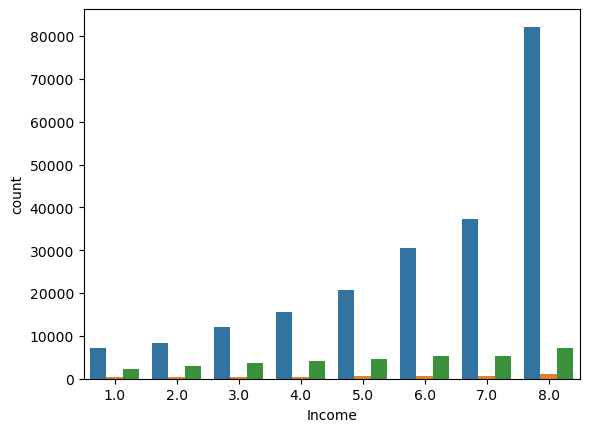

In [86]:
# Age group distribution
sns.countplot(x='Income', data=df, hue='Diabetes_012')
plt.title('Age Distribution')
plt.xlabel('Age Group | 1 = 18-24 ... 9 = 60-64 ... 13 = 80 or older')
plt.ylabel('Count')
plt.show()

In [52]:
df["BMI"].value_counts()

BMI
27.0    24606
26.0    20562
24.0    19550
25.0    17146
28.0    16545
        ...  
85.0        1
91.0        1
86.0        1
90.0        1
78.0        1
Name: count, Length: 84, dtype: int64

In [3]:
df.shape

(253680, 22)

In [4]:
#Check for any missing values
df.isnull().sum()

Diabetes_012            0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64

In [5]:
#Check for value of 0. BMI, GenHlth, Age, Education, and Income should never be 0
(df == 0).sum()

Diabetes_012            213703
HighBP                  144851
HighChol                146089
CholCheck                 9470
BMI                          0
Smoker                  141257
Stroke                  243388
HeartDiseaseorAttack    229787
PhysActivity             61760
Fruits                   92782
Veggies                  47839
HvyAlcoholConsump       239424
AnyHealthcare            12417
NoDocbcCost             232326
GenHlth                      0
MentHlth                175680
PhysHlth                160052
DiffWalk                211005
Sex                     141974
Age                          0
Education                    0
Income                       0
dtype: int64

In [14]:
df["Diabetes_012"].value_counts()

Diabetes_012
0.0    213703
2.0     35346
1.0      4631
Name: count, dtype: int64

<Axes: title={'center': 'Diagnosis'}, xlabel='Diabetes_012'>

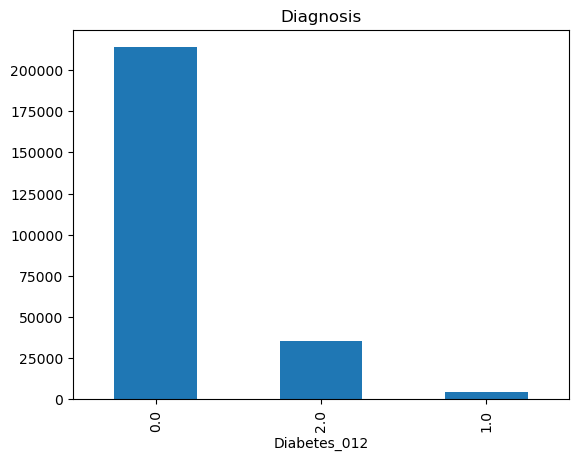

In [25]:
df["Diabetes_012"].value_counts().plot(kind="bar", title="Diagnosis")